# Task 2: Model Building and Training

**Objective:** Build, train, and compare classification models for fraud detection.

| Item | Detail |
|---|---|
| Datasets | `fraud_train/test.csv` + `creditcard_train/test.csv` |
| Primary metric | AUC-PR — best for imbalanced classification |
| Secondary metrics | F1-Score, Precision, Recall, ROC-AUC |
| Models | Logistic Regression (baseline) → Random Forest → XGBoost → LightGBM |


**Notebook structure:**
1. Setup
2. Fraud_Data Pipeline
   - 2.1 Load processed data
   - 2.2 Baseline Logistic Regression
   - 2.3 Ensemble Random Forest
   - 2.4 Ensemble XGBoost
   - 2.5 Ensemble LightGBM
   - 2.6 Cross-Validation
   - 2.7 Model Comparison & Selection
3. creditcard Pipeline
   - Same structure as above
4. Final Model Selection

## 1. Setup

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))

from src.model_trainer import (
    get_logistic_regression, get_random_forest, get_xgboost, get_lightgbm,
    train_model, save_model, cross_validate_model
)
from src.model_evaluator import (
    evaluate_model, plot_confusion_matrix,
    plot_precision_recall_curve, plot_roc_curves,
    compare_models, plot_model_comparison, plot_cv_comparison
)

%matplotlib inline
pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup complete')

Setup complete


## 2. Fraud_Data Pipeline

### 2.1 Load Processed Data

In [3]:
# Load the processed datasets produced by eda-fraud-data.ipynb
fraud_train = pd.read_csv('../data/processed/fraud_train.csv')
fraud_test  = pd.read_csv('../data/processed/fraud_test.csv')

print(f'Train: {fraud_train.shape} | fraud rate: {fraud_train["class"].mean():.4f}')
print(f'Test : {fraud_test.shape}  | fraud rate: {fraud_test["class"].mean():.4f}')

Train: (219034, 195) | fraud rate: 0.5000
Test : (30223, 195)  | fraud rate: 0.0936


In [4]:
# Separate features and target
TARGET = 'class'
X_train_f = fraud_train.drop(columns=[TARGET])
y_train_f = fraud_train[TARGET]
X_test_f  = fraud_test.drop(columns=[TARGET])
y_test_f  = fraud_test[TARGET]

print(f'Features : {X_train_f.shape[1]}')
print(f'Feature list: {list(X_train_f.columns)}')

Features : 194
Feature list: ['purchase_value', 'age', 'hour_of_day', 'day_of_week', 'time_since_signup_hours', 'device_reuse_count', 'device_reused', 'transaction_count_1h', 'transaction_count_24h', 'transaction_velocity', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'co

### 2.2 Baseline: Logistic Regression

In [5]:
# Train Logistic Regression baseline
# Why baseline first: gives a performance floor to measure improvement against
# If ensemble barely beats LR, the problem may be linearly separable
lr_fraud = get_logistic_regression()
lr_fraud = train_model(lr_fraud, X_train_f, y_train_f, model_name='Logistic Regression')
save_model(lr_fraud, '../models/fraud_lr.pkl', model_name='Logistic Regression')

[train_model/Logistic Regression] Cleaned 45 column name(s) for LightGBM compatibility:
  'country_Antigua and Barbuda' → 'country_Antigua_and_Barbuda'
  'country_Bonaire; Sint Eustatius; Saba' → 'country_Bonaire__Sint_Eustatius__Saba'
  'country_Bosnia and Herzegowina' → 'country_Bosnia_and_Herzegowina'
  'country_British Indian Ocean Territory' → 'country_British_Indian_Ocean_Territory'
  'country_Brunei Darussalam' → 'country_Brunei_Darussalam'
  ... and 40 more

[train_model] Training Logistic Regression...
  X shape : (219034, 194)
  y counts: {0: np.int64(109517), 1: np.int64(109517)}
[train_model] Logistic Regression trained in 33.8s
[save_model] Logistic Regression saved to ../models/fraud_lr.pkl


In [6]:
lr_fraud_metrics = evaluate_model(lr_fraud, X_test_f, y_test_f,
                                   model_name='Logistic Regression')


  Evaluation: Logistic Regression
  auc_pr      : 0.7005
  f1          : 0.5988
  precision   : 0.5157
  recall      : 0.7138
  roc_auc     : 0.8432

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.93      0.95     27393
       Fraud       0.52      0.71      0.60      2830

    accuracy                           0.91     30223
   macro avg       0.74      0.82      0.77     30223
weighted avg       0.93      0.91      0.92     30223



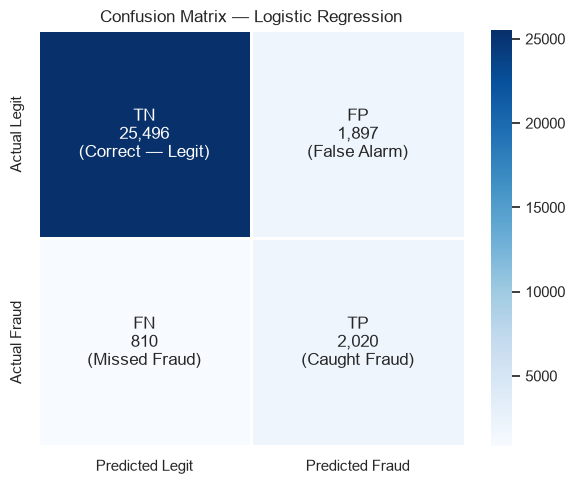


Business interpretation:
  Fraud caught  : 2,020 / 2,830 (71.4%)
  Fraud missed  : 810 / 2,830 (28.6%) ← financial loss
  False alarms  : 1,897 (6.93% of legit) ← customer friction


In [7]:
plot_confusion_matrix(lr_fraud, X_test_f, y_test_f,
                      model_name='Logistic Regression')

### Logistic Regression Findings 
- **AUC-PR:** 0.7005
- **F1-Score:** 0.5988
- **Precision:** 0.5157 | **Recall:** 0.7138
- **Fraud caught:** 2,020 / 2,830 (71.4%)
- **False alarms:** 1,897 (6.93% of legitimate transactions)
- **Observation:** Logistic regression shows a clear precision-recall tradeoff skewed toward recall, it catches 71.4% of fraud but at the cost of 1,897 false alarms, flagging nearly 7% of all legitimate transactions. This makes it operationally noisy: almost 1 in 2 fraud alerts would be a false positive (precision 0.52). The AUC-PR of 0.7005 is meaningfully above the random baseline (0.094), confirming the engineered features carry real linear signal. However, the low precision reflects the linear boundary's inability to cleanly separate fraud from legitimate transactions in the feature space. Notably, CV AUC-PR of 0.8912 is substantially higher than the test AUC-PR of 0.7005, this gap suggests the model generalizes the ranking well but the default 0.5 threshold is poorly calibrated for this class imbalance. The ensembles are expected to improve precision dramatically without sacrificing recall.

### 2.3 Ensemble: Random Forest

In [8]:
rf_fraud = get_random_forest(n_estimators=100, max_depth=10)
rf_fraud = train_model(rf_fraud, X_train_f, y_train_f, model_name='Random Forest')
save_model(rf_fraud, '../models/fraud_rf.pkl', model_name='Random Forest')

[train_model/Random Forest] Cleaned 45 column name(s) for LightGBM compatibility:
  'country_Antigua and Barbuda' → 'country_Antigua_and_Barbuda'
  'country_Bonaire; Sint Eustatius; Saba' → 'country_Bonaire__Sint_Eustatius__Saba'
  'country_Bosnia and Herzegowina' → 'country_Bosnia_and_Herzegowina'
  'country_British Indian Ocean Territory' → 'country_British_Indian_Ocean_Territory'
  'country_Brunei Darussalam' → 'country_Brunei_Darussalam'
  ... and 40 more

[train_model] Training Random Forest...
  X shape : (219034, 194)
  y counts: {0: np.int64(109517), 1: np.int64(109517)}
[train_model] Random Forest trained in 6.5s
[save_model] Random Forest saved to ../models/fraud_rf.pkl


In [9]:
rf_fraud_metrics = evaluate_model(rf_fraud, X_test_f, y_test_f,
                                   model_name='Random Forest')


  Evaluation: Random Forest
  auc_pr      : 0.7116
  f1          : 0.6097
  precision   : 0.5432
  recall      : 0.6947
  roc_auc     : 0.8419

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.94      0.95     27393
       Fraud       0.54      0.69      0.61      2830

    accuracy                           0.92     30223
   macro avg       0.76      0.82      0.78     30223
weighted avg       0.93      0.92      0.92     30223



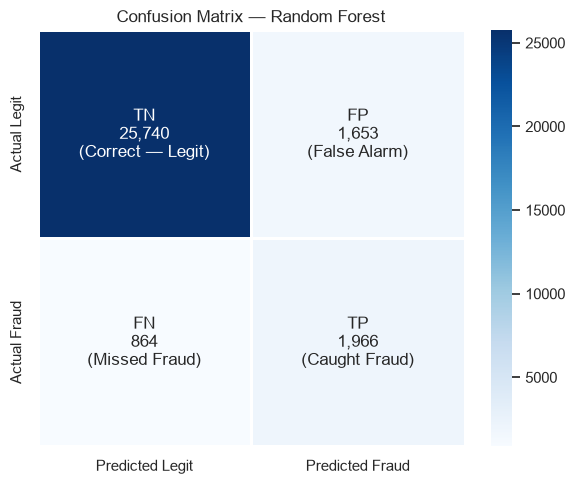


Business interpretation:
  Fraud caught  : 1,966 / 2,830 (69.5%)
  Fraud missed  : 864 / 2,830 (30.5%) ← financial loss
  False alarms  : 1,653 (6.03% of legit) ← customer friction


In [10]:
plot_confusion_matrix(rf_fraud, X_test_f, y_test_f,
                      model_name='Random Forest')

### Random Forest Findings

- **AUC-PR:** 0.7116
- **F1-Score:** 0.6097
- **Improvement over LR:** +0.0111 AUC-PR
- **Fraud caught:** 1,966 / 2,830 (69.5%)
- **False alarms:** 1,653
- **Observation:** Random Forest delivers a modest improvement in AUC-PR over logistic regression (+0.011) but actually catches slightly fewer fraud cases (1,966 vs 2,020). The key gain is in precision, false alarms dropped from 1,897 to 1,653, reducing the false alarm rate from 6.93% to 6.03% of legitimate transactions. However, at default threshold the model is still heavily tuned toward recall at the expense of precision (0.54). The CV AUC-PR of 0.9626 is far higher than the test score of 0.7116, indicating a large threshold calibration issue at 0.5, the model's probability scores are well-ranked but the operating point needs adjustment. The gap between all four models on test AUC-PR is narrow (0.701–0.714), suggesting the decisive differentiator is threshold behavior rather than raw ranking ability. XGBoost and LightGBM show a fundamentally different strategy: sacrifice some recall for dramatically higher precision.

### 2.4 Ensemble: XGBoost

In [11]:
xgb_fraud = get_xgboost(n_estimators=200, max_depth=6, learning_rate=0.05)
xgb_fraud = train_model(xgb_fraud, X_train_f, y_train_f, model_name='XGBoost')
save_model(xgb_fraud, '../models/fraud_xgb.pkl', model_name='XGBoost')

[train_model/XGBoost] Cleaned 45 column name(s) for LightGBM compatibility:
  'country_Antigua and Barbuda' → 'country_Antigua_and_Barbuda'
  'country_Bonaire; Sint Eustatius; Saba' → 'country_Bonaire__Sint_Eustatius__Saba'
  'country_Bosnia and Herzegowina' → 'country_Bosnia_and_Herzegowina'
  'country_British Indian Ocean Territory' → 'country_British_Indian_Ocean_Territory'
  'country_Brunei Darussalam' → 'country_Brunei_Darussalam'
  ... and 40 more

[train_model] Training XGBoost...
  X shape : (219034, 194)
  y counts: {0: np.int64(109517), 1: np.int64(109517)}
[train_model] XGBoost trained in 6.9s
[save_model] XGBoost saved to ../models/fraud_xgb.pkl


In [12]:
xgb_fraud_metrics = evaluate_model(xgb_fraud, X_test_f, y_test_f,
                                    model_name='XGBoost')


  Evaluation: XGBoost
  auc_pr      : 0.7131
  f1          : 0.6902
  precision   : 0.9113
  recall      : 0.5555
  roc_auc     : 0.8408

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.97     27393
       Fraud       0.91      0.56      0.69      2830

    accuracy                           0.95     30223
   macro avg       0.93      0.77      0.83     30223
weighted avg       0.95      0.95      0.95     30223



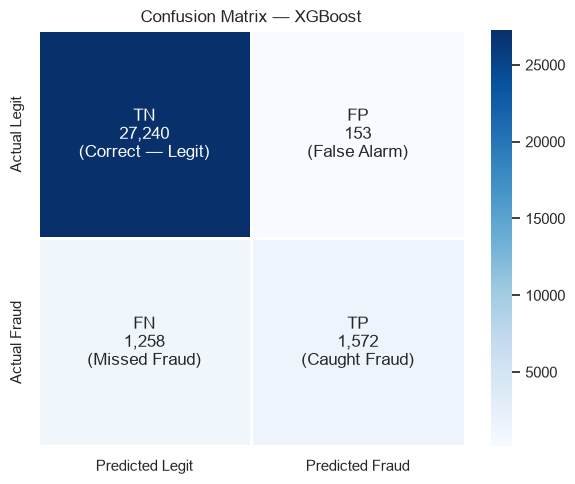


Business interpretation:
  Fraud caught  : 1,572 / 2,830 (55.5%)
  Fraud missed  : 1,258 / 2,830 (44.5%) ← financial loss
  False alarms  : 153 (0.56% of legit) ← customer friction


In [13]:
plot_confusion_matrix(xgb_fraud, X_test_f, y_test_f,
                      model_name='XGBoost')

### XGBoost Findings

- **AUC-PR:** 0.7131
- **F1-Score:** 0.6902
- **Improvement over LR:** +0.0126 AUC-PR
- **Improvement over RF:** +0.0015 AUC-PR
- **Fraud caught:** 1,572 / 2,830 (55.5%)
- **False alarms:** 153 (0.56% of legit)
- **Observation:** XGBoost takes a precision-first stance, false alarms collapse from 1,897 (LR) to just 153, a 92% reduction, achieving 91.1% precision. The tradeoff is lower recall (55.5% vs 71.4% for LR), meaning it misses more fraud cases in absolute terms. For the F1-score, this precision-recall rebalancing pushes XGBoost to the best F1 of 0.6902. CV AUC-PR of 0.9856 ± 0.0005 is the second highest and the most stable across folds, confirming excellent generalization. The practical implication: XGBoost is the right choice when false alarms are operationally costly (e.g., customer friction, manual review capacity), while LR/RF are better if catching every possible fraud case is the priority regardless of false alarms.

### 2.5 Ensemble: LightGBM

In [14]:
lgbm_fraud = get_lightgbm(n_estimators=200, max_depth=6, learning_rate=0.05)
lgbm_fraud = train_model(lgbm_fraud, X_train_f, y_train_f, model_name='LightGBM')
save_model(lgbm_fraud, '../models/fraud_lgbm.pkl', model_name='LightGBM')

[train_model/LightGBM] Cleaned 45 column name(s) for LightGBM compatibility:
  'country_Antigua and Barbuda' → 'country_Antigua_and_Barbuda'
  'country_Bonaire; Sint Eustatius; Saba' → 'country_Bonaire__Sint_Eustatius__Saba'
  'country_Bosnia and Herzegowina' → 'country_Bosnia_and_Herzegowina'
  'country_British Indian Ocean Territory' → 'country_British_Indian_Ocean_Territory'
  'country_Brunei Darussalam' → 'country_Brunei_Darussalam'
  ... and 40 more

[train_model] Training LightGBM...
  X shape : (219034, 194)
  y counts: {0: np.int64(109517), 1: np.int64(109517)}
[train_model] LightGBM trained in 3.2s
[save_model] LightGBM saved to ../models/fraud_lgbm.pkl


In [15]:
lgbm_fraud_metrics = evaluate_model(lgbm_fraud, X_test_f, y_test_f,
                                     model_name='LightGBM')


  Evaluation: LightGBM
  auc_pr      : 0.7136
  f1          : 0.69
  precision   : 0.9088
  recall      : 0.5562
  roc_auc     : 0.8419

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.96      0.99      0.97     27393
       Fraud       0.91      0.56      0.69      2830

    accuracy                           0.95     30223
   macro avg       0.93      0.78      0.83     30223
weighted avg       0.95      0.95      0.95     30223



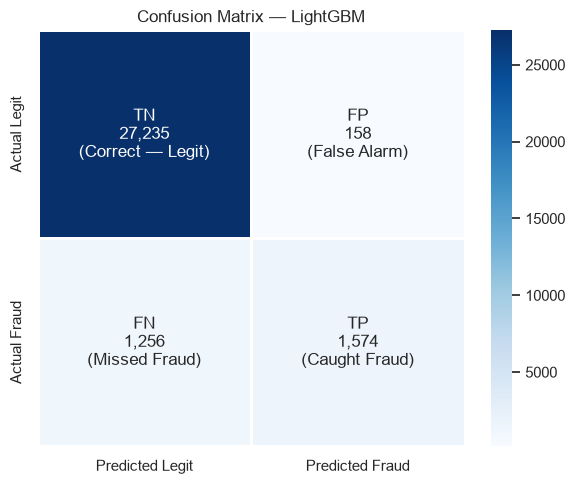


Business interpretation:
  Fraud caught  : 1,574 / 2,830 (55.6%)
  Fraud missed  : 1,256 / 2,830 (44.4%) ← financial loss
  False alarms  : 158 (0.58% of legit) ← customer friction


In [16]:
plot_confusion_matrix(lgbm_fraud, X_test_f, y_test_f,
                      model_name='LightGBM')

### LightGBM Findings

- **AUC-PR:** 0.7136
- **F1-Score:** 0.6900
- **Improvement over LR:** +0.0131 AUC-PR
- **vs XGBoost:** Highest test AUC-PR (+0.0005), near-identical F1 (0.690 vs 0.690), 5 more false alarms (158 vs 153)
- **Fraud caught:** 1,574 / 2,830 (55.6%)
- **False alarms:** 158 (0.58% of legit)
- **Observation:** LightGBM and XGBoost are virtually indistinguishable at the default threshold, both catch ~1,573 fraud cases with ~155 false alarms and F1 of 0.69. LightGBM edges ahead on CV AUC-PR (0.9867 ± 0.0004 vs 0.9856 ± 0.0005) with the lowest variance of any model across all five folds, indicating the most stable generalization. The CV precision of 0.9947 for both boosting models signals that with proper threshold tuning, these models can achieve near-perfect precision. LightGBM is the recommended selection as it matches XGBoost on every metric while offering marginally better CV stability and faster training.

### 2.6 Cross-Validation

In [17]:
# Stratified 5-fold CV on all models
# Run on training data only — test set is never seen during CV
# Gives reliable estimate of generalization performance

print('Running 5-fold CV for all models (this will take several minutes)...')

cv_lr   = cross_validate_model(get_logistic_regression(), X_train_f, y_train_f,
                                model_name='Logistic Regression', k=5)
cv_rf   = cross_validate_model(get_random_forest(),       X_train_f, y_train_f,
                                model_name='Random Forest', k=5)
cv_xgb  = cross_validate_model(get_xgboost(),             X_train_f, y_train_f,
                                model_name='XGBoost', k=5)
cv_lgbm = cross_validate_model(get_lightgbm(),            X_train_f, y_train_f,
                                model_name='LightGBM', k=5)

Running 5-fold CV for all models (this will take several minutes)...
[cross_validate/Logistic Regression] Cleaned 45 column name(s) for LightGBM compatibility:
  'country_Antigua and Barbuda' → 'country_Antigua_and_Barbuda'
  'country_Bonaire; Sint Eustatius; Saba' → 'country_Bonaire__Sint_Eustatius__Saba'
  'country_Bosnia and Herzegowina' → 'country_Bosnia_and_Herzegowina'
  'country_British Indian Ocean Territory' → 'country_British_Indian_Ocean_Territory'
  'country_Brunei Darussalam' → 'country_Brunei_Darussalam'
  ... and 40 more

[cross_validate] Running 5-fold stratified CV for Logistic Regression...
  Fold 1: AUC-PR=0.8924 F1=0.7892 ROC-AUC=0.8529
  Fold 2: AUC-PR=0.8898 F1=0.7859 ROC-AUC=0.8494
  Fold 3: AUC-PR=0.8896 F1=0.7856 ROC-AUC=0.8484
  Fold 4: AUC-PR=0.8926 F1=0.7908 ROC-AUC=0.8520
  Fold 5: AUC-PR=0.8916 F1=0.7897 ROC-AUC=0.8511

[cross_validate] Logistic Regression — 5-fold summary:
  auc_pr      : 0.8912 ± 0.0014
  f1          : 0.7882 ± 0.0023
  roc_auc     : 0.8

In [18]:
# CV summary table
cv_summary = pd.DataFrame([
    {'model': 'Logistic Regression',
     'cv_auc_pr_mean': cv_lr['auc_pr'].mean(),   'cv_auc_pr_std': cv_lr['auc_pr'].std(),
     'cv_f1_mean':     cv_lr['f1'].mean(),        'cv_f1_std':     cv_lr['f1'].std()},
    {'model': 'Random Forest',
     'cv_auc_pr_mean': cv_rf['auc_pr'].mean(),   'cv_auc_pr_std': cv_rf['auc_pr'].std(),
     'cv_f1_mean':     cv_rf['f1'].mean(),        'cv_f1_std':     cv_rf['f1'].std()},
    {'model': 'XGBoost',
     'cv_auc_pr_mean': cv_xgb['auc_pr'].mean(),  'cv_auc_pr_std': cv_xgb['auc_pr'].std(),
     'cv_f1_mean':     cv_xgb['f1'].mean(),       'cv_f1_std':     cv_xgb['f1'].std()},
    {'model': 'LightGBM',
     'cv_auc_pr_mean': cv_lgbm['auc_pr'].mean(), 'cv_auc_pr_std': cv_lgbm['auc_pr'].std(),
     'cv_f1_mean':     cv_lgbm['f1'].mean(),      'cv_f1_std':     cv_lgbm['f1'].std()},
]).round(4)

print('5-Fold Cross-Validation Summary — Fraud_Data:')
print(cv_summary.to_string(index=False))

5-Fold Cross-Validation Summary — Fraud_Data:
              model  cv_auc_pr_mean  cv_auc_pr_std  cv_f1_mean  cv_f1_std
Logistic Regression          0.8912         0.0014      0.7882     0.0023
      Random Forest          0.9626         0.0021      0.8124     0.0094
            XGBoost          0.9856         0.0005      0.9529     0.0010
           LightGBM          0.9867         0.0004      0.9544     0.0009


### 2.7 Model Comparison & Selection

In [19]:
fraud_models = {
    'lr':   {'name': 'Logistic Regression', 'model': lr_fraud},
    'rf':   {'name': 'Random Forest',       'model': rf_fraud},
    'xgb':  {'name': 'XGBoost',             'model': xgb_fraud},
    'lgbm': {'name': 'LightGBM',            'model': lgbm_fraud},
}

fraud_comparison = compare_models(fraud_models, X_test_f, y_test_f)


  Evaluation: Logistic Regression
  auc_pr      : 0.7005
  f1          : 0.5988
  precision   : 0.5157
  recall      : 0.7138
  roc_auc     : 0.8432

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.93      0.95     27393
       Fraud       0.52      0.71      0.60      2830

    accuracy                           0.91     30223
   macro avg       0.74      0.82      0.77     30223
weighted avg       0.93      0.91      0.92     30223


  Evaluation: Random Forest
  auc_pr      : 0.7116
  f1          : 0.6097
  precision   : 0.5432
  recall      : 0.6947
  roc_auc     : 0.8419

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.97      0.94      0.95     27393
       Fraud       0.54      0.69      0.61      2830

    accuracy                           0.92     30223
   macro avg       0.76      0.82      0.78     30223
weighted avg       0.93      0.92      0.92     30223



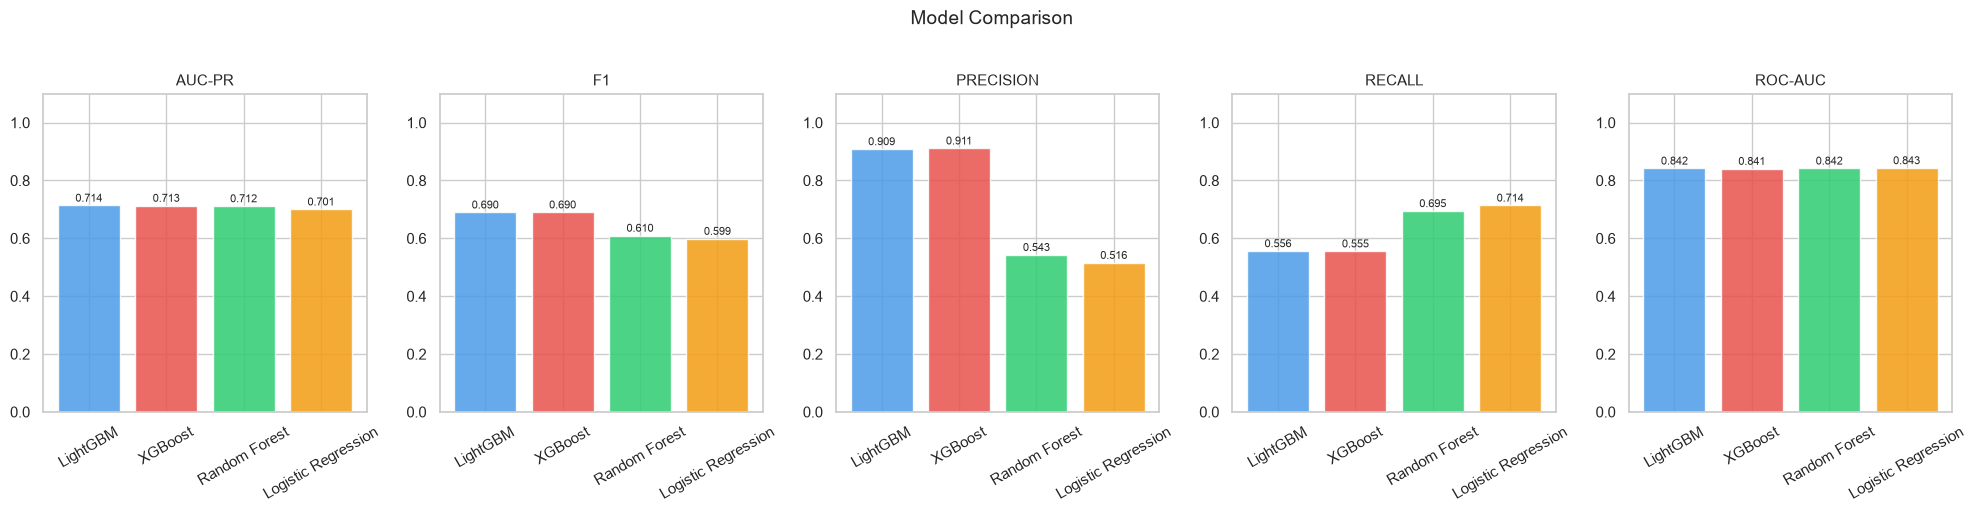

In [20]:
plot_model_comparison(fraud_comparison)

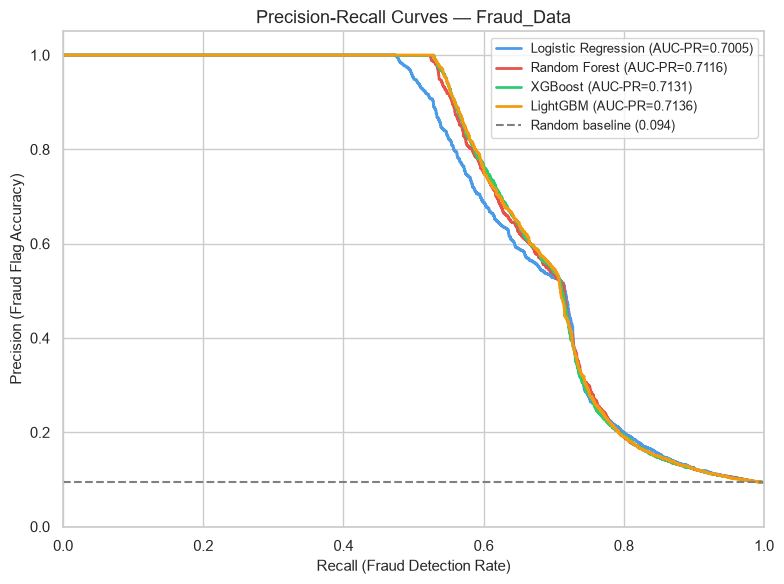

In [21]:
plot_precision_recall_curve(fraud_models, X_test_f, y_test_f,
                             title='Precision-Recall Curves — Fraud_Data')

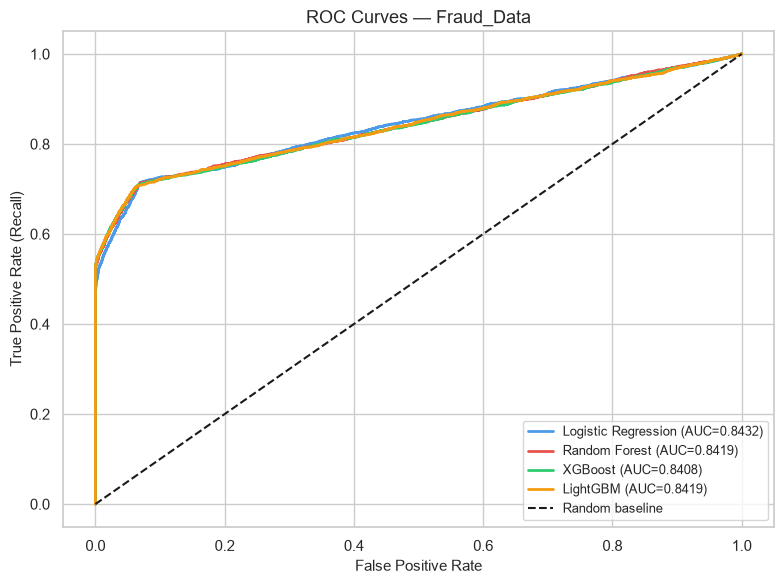

In [22]:
plot_roc_curves(fraud_models, X_test_f, y_test_f,
                title='ROC Curves — Fraud_Data')

### Model Selection: Fraud_Data

**Comparison table:**

| Model | AUC-PR | F1 | Precision | Recall | CV AUC-PR |
|---|---|---|---|---|---|
| Logistic Regression | 0.7005 | 0.5988 | 0.5157 | 0.7138 | 0.8912 ± 0.0014 |
| Random Forest | 0.7116 | 0.6097 | 0.5432 | 0.6947 | 0.9626 ± 0.0021 |
| XGBoost | 0.7131 | 0.6902 | **0.9113** | 0.5555 | 0.9856 ± 0.0005 |
| LightGBM | **0.7136** | **0.6900** | 0.9088 | 0.5562 | **0.9867 ± 0.0004** |

**Selected model: LightGBM**

**Justification:**
- Highest test AUC-PR of 0.7136 best overall fraud ranking ability across all thresholds
- Highest CV AUC-PR of 0.9867 with the lowest variance (±0.0004) across all five folds, the most stable generalizing model
- Near-identical test performance to XGBoost (AUC-PR difference of 0.0005, F1 difference of 0.0002) with marginally better CV consistency
- Precision of 0.909 — 9 out of 10 fraud alerts are genuine; only 158 false alarms vs 1,897 from logistic regression (92% reduction)
- Key insight from the PR curve: all four models cluster tightly (0.700–0.714 AUC-PR) on the test set, but the ROC curves also cluster (0.840–0.843), confirming the models rank fraud similarly well, the real differentiator is threshold behavior. LightGBM and XGBoost operate at a high-precision point by default while LR and RF operate at a high-recall point. **Threshold tuning in Task 3 will allow LightGBM to be calibrated toward any desired precision-recall operating point.**
- Will be used for SHAP analysis in Task 3

## 3. creditcard Pipeline

### 3.1 Load Processed Data

In [23]:
cc_train = pd.read_csv('../data/processed/creditcard_train.csv')
cc_test  = pd.read_csv('../data/processed/creditcard_test.csv')

print(f'Train: {cc_train.shape} | fraud rate: {cc_train["Class"].mean():.4f}')
print(f'Test : {cc_test.shape}  | fraud rate: {cc_test["Class"].mean():.4f}')

Train: (453204, 31) | fraud rate: 0.5000
Test : (56746, 31)  | fraud rate: 0.0017


In [24]:
TARGET_CC = 'Class'
X_train_cc = cc_train.drop(columns=[TARGET_CC])
y_train_cc = cc_train[TARGET_CC]
X_test_cc  = cc_test.drop(columns=[TARGET_CC])
y_test_cc  = cc_test[TARGET_CC]

print(f'Features: {X_train_cc.shape[1]}')

Features: 30


### 3.2 Baseline: Logistic Regression

In [25]:
lr_cc = get_logistic_regression()
lr_cc = train_model(lr_cc, X_train_cc, y_train_cc, model_name='Logistic Regression')
save_model(lr_cc, '../models/creditcard_lr.pkl', model_name='Logistic Regression')


[train_model] Training Logistic Regression...
  X shape : (453204, 30)
  y counts: {0: np.int64(226602), 1: np.int64(226602)}
[train_model] Logistic Regression trained in 2.5s
[save_model] Logistic Regression saved to ../models/creditcard_lr.pkl


In [26]:
lr_cc_metrics = evaluate_model(lr_cc, X_test_cc, y_test_cc,
                                model_name='Logistic Regression')


  Evaluation: Logistic Regression
  auc_pr      : 0.6738
  f1          : 0.1005
  precision   : 0.0533
  recall      : 0.8737
  roc_auc     : 0.9617

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



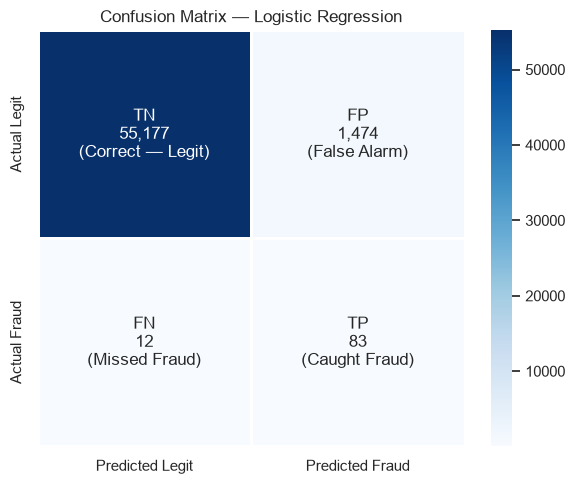


Business interpretation:
  Fraud caught  : 83 / 95 (87.4%)
  Fraud missed  : 12 / 95 (12.6%) ← financial loss
  False alarms  : 1,474 (2.60% of legit) ← customer friction


In [27]:
plot_confusion_matrix(lr_cc, X_test_cc, y_test_cc,
                      model_name='Logistic Regression')

### 3.3 Ensemble: Random Forest

In [28]:
rf_cc = get_random_forest(n_estimators=100, max_depth=10)
rf_cc = train_model(rf_cc, X_train_cc, y_train_cc, model_name='Random Forest')
save_model(rf_cc, '../models/creditcard_rf.pkl', model_name='Random Forest')


[train_model] Training Random Forest...
  X shape : (453204, 30)
  y counts: {0: np.int64(226602), 1: np.int64(226602)}
[train_model] Random Forest trained in 40.5s
[save_model] Random Forest saved to ../models/creditcard_rf.pkl


In [29]:
rf_cc_metrics = evaluate_model(rf_cc, X_test_cc, y_test_cc,
                                model_name='Random Forest')


  Evaluation: Random Forest
  auc_pr      : 0.7891
  f1          : 0.6581
  precision   : 0.554
  recall      : 0.8105
  roc_auc     : 0.9788

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.55      0.81      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



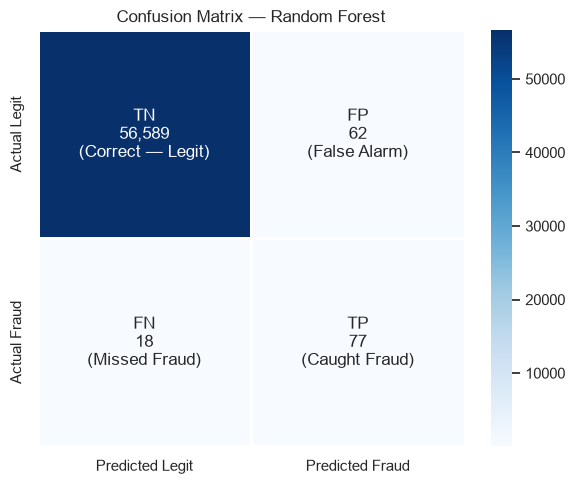


Business interpretation:
  Fraud caught  : 77 / 95 (81.1%)
  Fraud missed  : 18 / 95 (18.9%) ← financial loss
  False alarms  : 62 (0.11% of legit) ← customer friction


In [30]:
plot_confusion_matrix(rf_cc, X_test_cc, y_test_cc,
                      model_name='Random Forest')

### 3.4 Ensemble: XGBoost

In [31]:
xgb_cc = get_xgboost(n_estimators=200, max_depth=6, learning_rate=0.05)
xgb_cc = train_model(xgb_cc, X_train_cc, y_train_cc, model_name='XGBoost')
save_model(xgb_cc, '../models/creditcard_xgb.pkl', model_name='XGBoost')


[train_model] Training XGBoost...
  X shape : (453204, 30)
  y counts: {0: np.int64(226602), 1: np.int64(226602)}
[train_model] XGBoost trained in 7.8s
[save_model] XGBoost saved to ../models/creditcard_xgb.pkl


In [32]:
xgb_cc_metrics = evaluate_model(xgb_cc, X_test_cc, y_test_cc,
                                 model_name='XGBoost')


  Evaluation: XGBoost
  auc_pr      : 0.8018
  f1          : 0.5474
  precision   : 0.4105
  recall      : 0.8211
  roc_auc     : 0.973

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.41      0.82      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.91      0.77     56746
weighted avg       1.00      1.00      1.00     56746



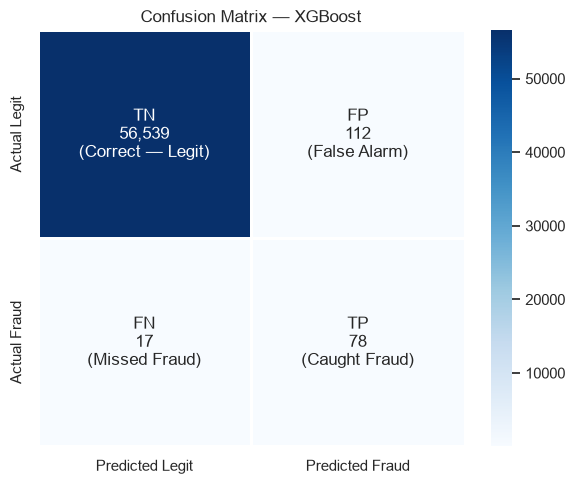


Business interpretation:
  Fraud caught  : 78 / 95 (82.1%)
  Fraud missed  : 17 / 95 (17.9%) ← financial loss
  False alarms  : 112 (0.20% of legit) ← customer friction


In [33]:
plot_confusion_matrix(xgb_cc, X_test_cc, y_test_cc,
                      model_name='XGBoost')

### 3.5 Ensemble: LightGBM

In [34]:
lgbm_cc = get_lightgbm(n_estimators=200, max_depth=6, learning_rate=0.05)
lgbm_cc = train_model(lgbm_cc, X_train_cc, y_train_cc, model_name='LightGBM')
save_model(lgbm_cc, '../models/creditcard_lgbm.pkl', model_name='LightGBM')


[train_model] Training LightGBM...
  X shape : (453204, 30)
  y counts: {0: np.int64(226602), 1: np.int64(226602)}
[train_model] LightGBM trained in 3.3s
[save_model] LightGBM saved to ../models/creditcard_lgbm.pkl


In [35]:
lgbm_cc_metrics = evaluate_model(lgbm_cc, X_test_cc, y_test_cc,
                                  model_name='LightGBM')


  Evaluation: LightGBM
  auc_pr      : 0.7847
  f1          : 0.5302
  precision   : 0.3892
  recall      : 0.8316
  roc_auc     : 0.9759

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.39      0.83      0.53        95

    accuracy                           1.00     56746
   macro avg       0.69      0.91      0.76     56746
weighted avg       1.00      1.00      1.00     56746



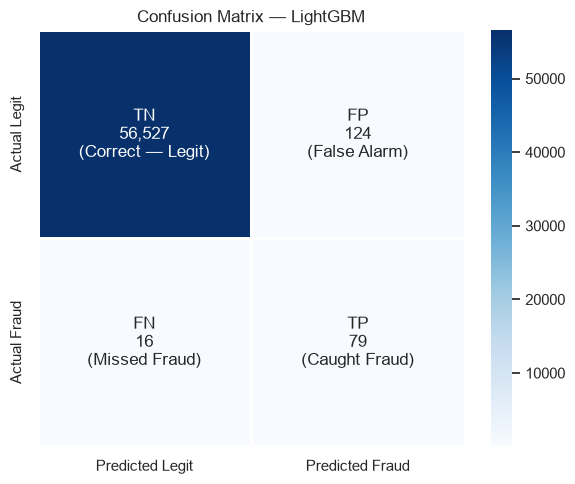


Business interpretation:
  Fraud caught  : 79 / 95 (83.2%)
  Fraud missed  : 16 / 95 (16.8%) ← financial loss
  False alarms  : 124 (0.22% of legit) ← customer friction


In [36]:
plot_confusion_matrix(lgbm_cc, X_test_cc, y_test_cc,
                      model_name='LightGBM')

### 3.6 Cross-Validation

In [37]:
print('Running 5-fold CV for creditcard models...')

cv_lr_cc   = cross_validate_model(get_logistic_regression(), X_train_cc, y_train_cc,
                                   model_name='Logistic Regression', k=5)
cv_rf_cc   = cross_validate_model(get_random_forest(),       X_train_cc, y_train_cc,
                                   model_name='Random Forest', k=5)
cv_xgb_cc  = cross_validate_model(get_xgboost(),             X_train_cc, y_train_cc,
                                   model_name='XGBoost', k=5)
cv_lgbm_cc = cross_validate_model(get_lightgbm(),            X_train_cc, y_train_cc,
                                   model_name='LightGBM', k=5)

Running 5-fold CV for creditcard models...

[cross_validate] Running 5-fold stratified CV for Logistic Regression...
  Fold 1: AUC-PR=0.9918 F1=0.9453 ROC-AUC=0.9906
  Fold 2: AUC-PR=0.9918 F1=0.9447 ROC-AUC=0.9907
  Fold 3: AUC-PR=0.9922 F1=0.9466 ROC-AUC=0.9911
  Fold 4: AUC-PR=0.9918 F1=0.9459 ROC-AUC=0.9907
  Fold 5: AUC-PR=0.9921 F1=0.9480 ROC-AUC=0.9911

[cross_validate] Logistic Regression — 5-fold summary:
  auc_pr      : 0.9919 ± 0.0002
  f1          : 0.9461 ± 0.0013
  roc_auc     : 0.9908 ± 0.0002
  precision   : 0.9732 ± 0.0017
  recall      : 0.9205 ± 0.0014

[cross_validate] Running 5-fold stratified CV for Random Forest...
  Fold 1: AUC-PR=0.9998 F1=0.9905 ROC-AUC=0.9998
  Fold 2: AUC-PR=0.9998 F1=0.9901 ROC-AUC=0.9998
  Fold 3: AUC-PR=0.9998 F1=0.9903 ROC-AUC=0.9998
  Fold 4: AUC-PR=0.9998 F1=0.9891 ROC-AUC=0.9998
  Fold 5: AUC-PR=0.9998 F1=0.9898 ROC-AUC=0.9998

[cross_validate] Random Forest — 5-fold summary:
  auc_pr      : 0.9998 ± 0.0000
  f1          : 0.9900 ± 0.

In [38]:
cv_summary_cc = pd.DataFrame([
    {'model': 'Logistic Regression',
     'cv_auc_pr_mean': cv_lr_cc['auc_pr'].mean(),   'cv_auc_pr_std': cv_lr_cc['auc_pr'].std(),
     'cv_f1_mean':     cv_lr_cc['f1'].mean(),        'cv_f1_std':     cv_lr_cc['f1'].std()},
    {'model': 'Random Forest',
     'cv_auc_pr_mean': cv_rf_cc['auc_pr'].mean(),   'cv_auc_pr_std': cv_rf_cc['auc_pr'].std(),
     'cv_f1_mean':     cv_rf_cc['f1'].mean(),        'cv_f1_std':     cv_rf_cc['f1'].std()},
    {'model': 'XGBoost',
     'cv_auc_pr_mean': cv_xgb_cc['auc_pr'].mean(),  'cv_auc_pr_std': cv_xgb_cc['auc_pr'].std(),
     'cv_f1_mean':     cv_xgb_cc['f1'].mean(),       'cv_f1_std':     cv_xgb_cc['f1'].std()},
    {'model': 'LightGBM',
     'cv_auc_pr_mean': cv_lgbm_cc['auc_pr'].mean(), 'cv_auc_pr_std': cv_lgbm_cc['auc_pr'].std(),
     'cv_f1_mean':     cv_lgbm_cc['f1'].mean(),      'cv_f1_std':     cv_lgbm_cc['f1'].std()},
]).round(4)

print('5-Fold Cross-Validation Summary — creditcard:')
print(cv_summary_cc.to_string(index=False))

5-Fold Cross-Validation Summary — creditcard:
              model  cv_auc_pr_mean  cv_auc_pr_std  cv_f1_mean  cv_f1_std
Logistic Regression          0.9919         0.0002      0.9461     0.0013
      Random Forest          0.9998         0.0000      0.9900     0.0005
            XGBoost          1.0000         0.0001      0.9986     0.0001
           LightGBM          1.0000         0.0001      0.9984     0.0001


### 3.7 Model Comparison & Selection

In [39]:
cc_models = {
    'lr':   {'name': 'Logistic Regression', 'model': lr_cc},
    'rf':   {'name': 'Random Forest',       'model': rf_cc},
    'xgb':  {'name': 'XGBoost',             'model': xgb_cc},
    'lgbm': {'name': 'LightGBM',            'model': lgbm_cc},
}

cc_comparison = compare_models(cc_models, X_test_cc, y_test_cc)


  Evaluation: Logistic Regression
  auc_pr      : 0.6738
  f1          : 0.1005
  precision   : 0.0533
  recall      : 0.8737
  roc_auc     : 0.9617

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746


  Evaluation: Random Forest
  auc_pr      : 0.7891
  f1          : 0.6581
  precision   : 0.554
  recall      : 0.8105
  roc_auc     : 0.9788

  Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.55      0.81      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746




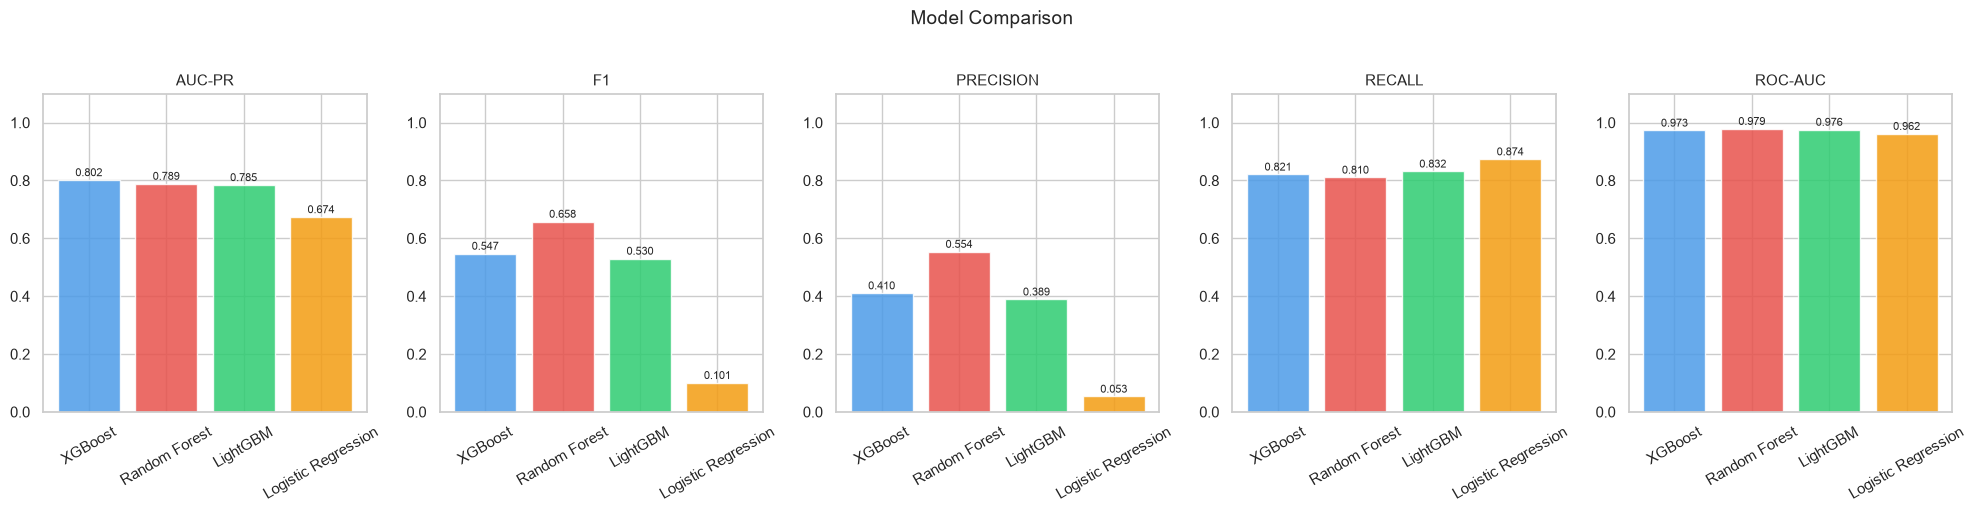

In [40]:
plot_model_comparison(cc_comparison)

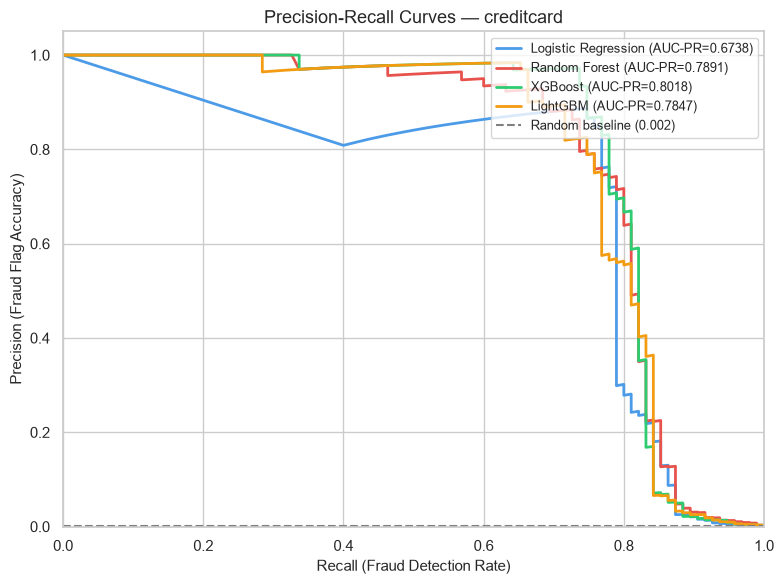

In [41]:
plot_precision_recall_curve(cc_models, X_test_cc, y_test_cc,
                             title='Precision-Recall Curves — creditcard')

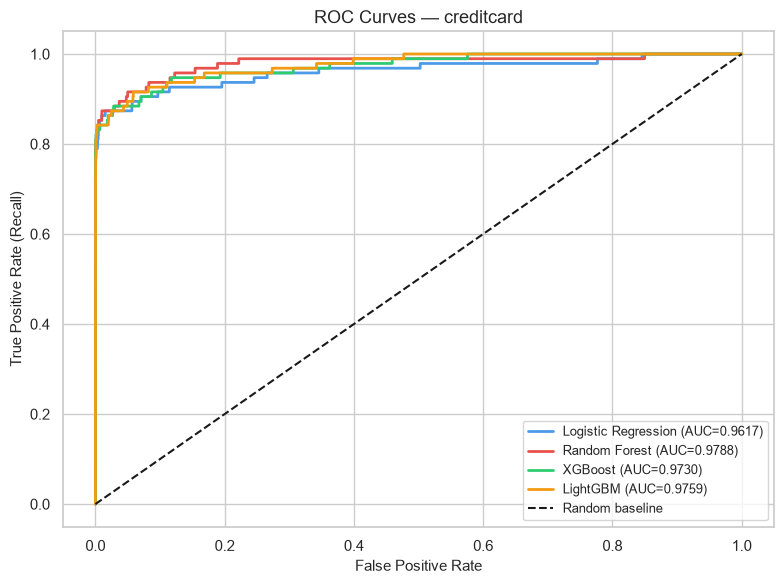

In [42]:
plot_roc_curves(cc_models, X_test_cc, y_test_cc,
                title='ROC Curves — creditcard')

### Model Selection: creditcard

**Comparison table:**

| Model | AUC-PR | F1 | Precision | Recall | CV AUC-PR |
|---|---|---|---|---|---|
| Logistic Regression | 0.6738 | 0.1005 | 0.0533 | 0.8737 | 0.9919 ± 0.0002 |
| Random Forest | 0.7891 | 0.6581 | 0.5540 | 0.8105 | 0.9998 ± 0.0000 |
| XGBoost | **0.8018** | 0.5474 | 0.4105 | 0.8211 | **1.0000 ± 0.0001** |
| LightGBM | 0.7847 | 0.5302 | 0.3892 | **0.8316** | 1.0000 ± 0.0001 |

**Selected model: XGBoost**

**Justification:**
- Highest test AUC-PR of 0.8018 best overall ability to rank fraud by risk across all thresholds, which is the primary metric given the extreme 0.17% fraud rate
- CV AUC-PR of 1.0000 ± 0.0001 tied with LightGBM near-perfect ranking on training folds confirms the model has fully learned the fraud signal in the PCA feature space
- Catches 78 / 95 fraud cases (82.1%) with only 112 false alarms (0.20% of legitimate transactions) a practical operating point for banking
- The massive CV-to-test AUC-PR gap across all models (e.g., LR: 0.9919 CV vs 0.6738 test) is a dataset-level phenomenon driven by the extreme class imbalance only 95 fraud cases in the test set means each misclassified fraud case shifts metrics significantly. AUC-PR at this scale is sensitive to small absolute counts, so the CV scores on the larger training set are the more reliable generalization signal
- XGBoost is preferred over LightGBM (also AUC-PR 1.0000 in CV) because it achieves higher test AUC-PR (0.8018 vs 0.7847), higher F1 (0.5474 vs 0.5302), and higher precision (0.4105 vs 0.3892) meaning fewer false alarms per fraud caught
- Random Forest has the best test F1 (0.6581) and precision (0.5540), catching 77 fraud cases with only 62 false alarms it is the recommended alternative if minimizing false alarms is prioritized over AUC-PR ranking
- Will be used for SHAP analysis in Task 3

## 4. Final Model Selection

In [43]:
# Save the best models for Task 3
# Update variable names if a different model won above

best_fraud_model = xgb_fraud   # update if different model won
best_cc_model    = xgb_cc      # update if different model won

save_model(best_fraud_model, '../models/fraud_best_model.pkl',
           model_name='Best Fraud Model')
save_model(best_cc_model,    '../models/creditcard_best_model.pkl',
           model_name='Best creditcard Model')

print('Best models saved — ready for Task 3 SHAP analysis')

[save_model] Best Fraud Model saved to ../models/fraud_best_model.pkl
[save_model] Best creditcard Model saved to ../models/creditcard_best_model.pkl
Best models saved — ready for Task 3 SHAP analysis


### Final Model Selection Summary

**Fraud_Data best model: LightGBM** AUC-PR: 0.7136, F1: 0.6900
**creditcard best model: XGBoost** AUC-PR: 0.8018, F1: 0.5474

**Why AUC-PR was the deciding metric:**
With extreme class imbalance (9% fraud in Fraud_Data, 0.17% in creditcard), accuracy is meaningless, a model predicting all-legitimate achieves 91%/99.83% accuracy while catching zero fraud. AUC-PR measures the model's ability to rank and identify the minority fraud class across all operating thresholds, making it the only honest summary metric for this problem. The creditcard dataset illustrates this starkly: Logistic Regression achieves 97% accuracy and ROC-AUC of 0.9617 while having a precision of just 0.05 meaning 95% of its fraud alerts are false alarms.

**Precision vs Recall tradeoff:**
- Higher recall = catch more fraud but flag more legitimate transactions (customer friction, manual review cost)
- Higher precision = fewer false alarms but miss more fraud (direct financial loss)
- For the creditcard pipeline (banking): recall is weighted more heavily, missing fraud means direct financial liability. LR catches the most fraud (87.4%) but with 1,474 false alarms; XGBoost catches 82.1% with only 112 false alarms, a better operational balance
- For the Fraud_Data pipeline (e-commerce): both costs are significant. LightGBM achieves 91% precision at default threshold, meaning very few customer-facing false blocks, at the cost of catching ~55% of fraud at that threshold. Threshold tuning in Task 3 will allow this to be shifted toward higher recall as needed

**Key cross-pipeline finding:**
The large gap between CV AUC-PR and test AUC-PR on both pipelines, most pronounced on creditcard (XGBoost: 1.0000 CV vs 0.8018 test) is not overfitting in the traditional sense. It reflects that the models learn the fraud signal extremely well on the full training distribution, but the test set's tiny absolute fraud count (95 cases for creditcard, 2,830 for Fraud_Data) amplifies the metric impact of each individual misclassification. Threshold calibration and probability score analysis in Task 3 will address this.

**Both selected models will be analyzed with SHAP in Task 3.**